In [24]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Quantum
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector

# 2 Fast and Quantum Fourier Transform (20 Points)
------
The Fast Fourier Transform (FFT) is a staple classical computing algorithm performing the Discrete Fourier Transform (DFT) that enables a lot of scientific computing and signal processing around us. Utilizing the symmetry of the Fourier Transform, the algorithm reduced the complexity from $O(N^2)$ to $O(N\cdot log(N))$.

Consider a raw measured signal $x(t)$ which we would like to analyze. The signal is sampled for times: $t_i$ where $i=0$ to $N-1$, providing an array of values. The DFT can be represented as the transformation :

$$ X_k = \sum_{i}^{N} x_i \exp \left( -2\pi j \frac{ik}{N} \right) $$

A real-valued amplitude normalized signal over 1 second, sampled 1024 times is provided with the ‘.csv’ data file: ‘raw signal data.csv’.


## Question 1 
------
Import this data and implement an FFT script of your choice to analyze the signal. We would like to find:

1. Alongside the raw signal, plot the analyzed frequency components as a plot of: Magnitude (relative units) v/s Frequency (in Hz).
2. Estimate the relative phase difference between the frequency components.

Freq: 5.00 Hz | Mag: 0.46 | Phase: -1.57 rad
Freq: 10.00 Hz | Mag: 0.30 | Phase: 0.09 rad
Freq: 30.00 Hz | Mag: 0.29 | Phase: -0.71 rad


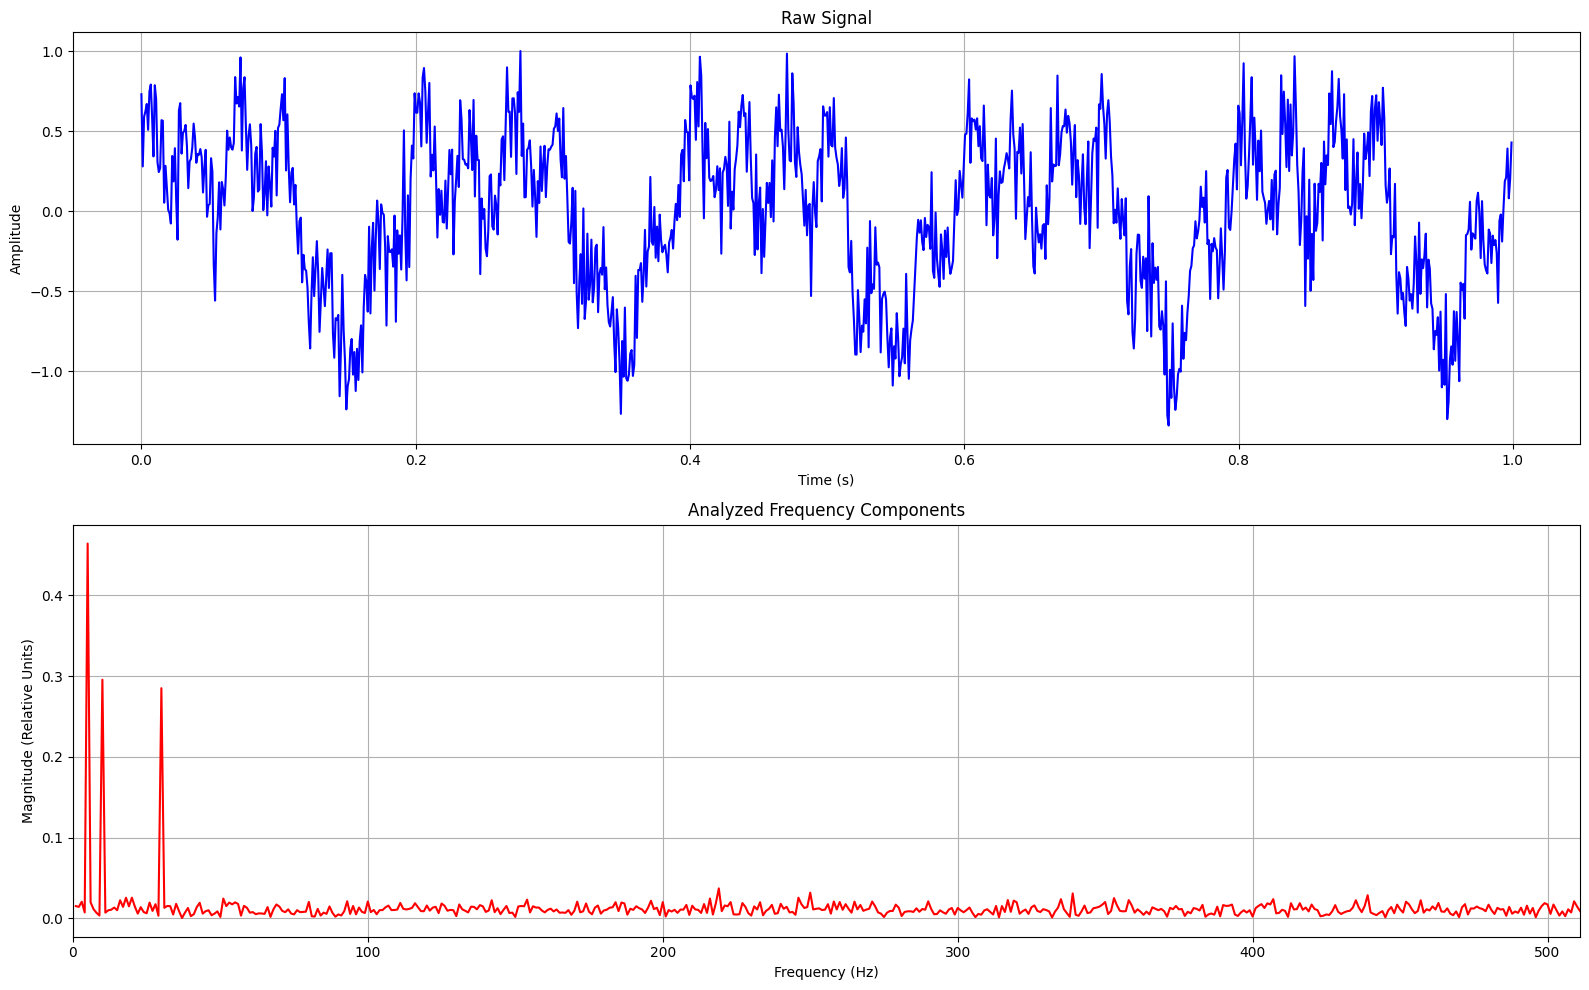

In [25]:
# Load the Datafile
df = pd.read_csv('raw_signal_data.csv', header=None, skiprows=1)
signal = df.iloc[:, 1].values
signal = signal.astype(float)

# Define some of the data properties
N = 1024
T = 1.0
dt = T / N

# Create a Time Array
t = np.linspace(0, T, N, endpoint=False)

# Compute the Fast Fourier Transform
FFTResult = np.fft.fft(signal)

# Get the Frequency bins
frequencies = np.fft.fftfreq(N, d=dt)

# Get the Positive / Nyquist Frequencies only
NyquistMask = frequencies > 0
NyquistFreq = frequencies[NyquistMask]
NyquistFFT = FFTResult[NyquistMask]

# Compute the Magnitudes of the Frequencies
Magnitudes = 2.0 / N * np.abs(NyquistFFT)

# Compute the Phase
Phase = np.angle(NyquistFFT)

# Display the frequencies that have magntiudes larger than 10% of the Max magnitude
threshold = np.max(Magnitudes) * 0.1
PeakIndices = np.where(Magnitudes > threshold)[0]

for idx in PeakIndices:
    print(f"Freq: {NyquistFreq[idx]:.2f} Hz | Mag: {Magnitudes[idx]:.2f} | Phase: {Phase[idx]:.2f} rad")


# Plot the Data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot the Raw Signal
ax1.plot(t, signal, color='blue')
ax1.set_title('Raw Signal')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.grid(True)

# Plot the Magnitudes vs Frequency
ax2.plot(NyquistFreq, Magnitudes, color='red')
ax2.set_title('Analyzed Frequency Components')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude (Relative Units)')
ax2.set_xlim(0, max(NyquistFreq)) # Limit to positive frequencies
ax2.grid(True)

plt.tight_layout()
plt.show()


## Question 2 
------
Implement this analysis on a quantum computer using the Quantum Fourier Transform. Sketch how the raw data can be represented in terms of the qubits and how the corresponding quantum circuit would look like.


[0.04747176 0.01814733 0.03830381 ... 0.00518867 0.01304969 0.02785495]


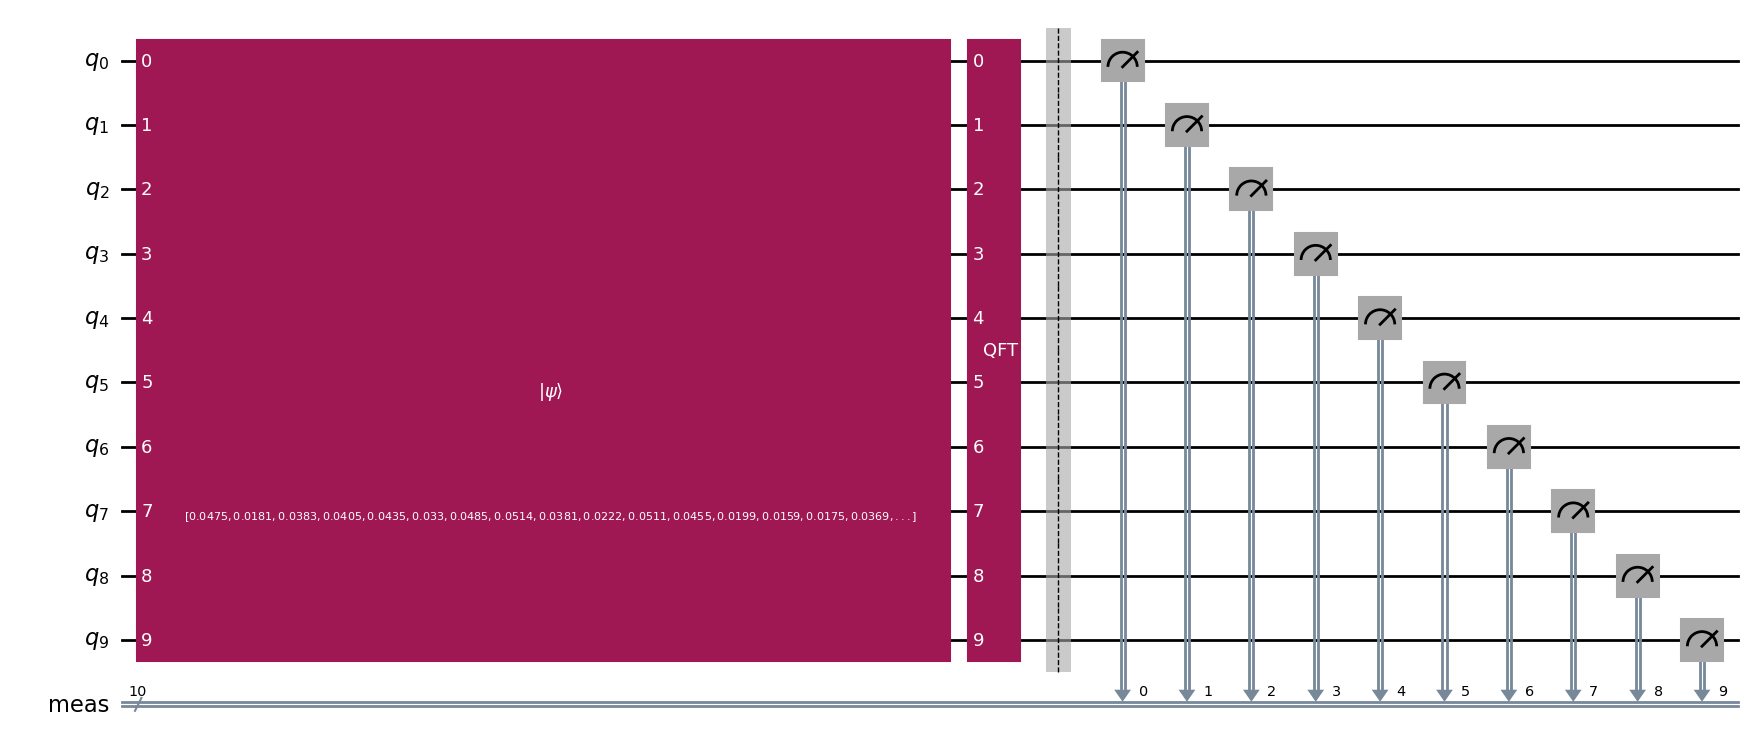

In [26]:
# Load the Datafile
df = pd.read_csv('raw_signal_data.csv', header=None, skiprows=1)
signal = df.iloc[:, 1].values
signal = signal.astype(float)

# Normalize the Signal
NormalizedSignal = signal / np.linalg.norm(signal)
print(NormalizedSignal)

# Create the Quantum Circuit
NQubits = 10
qc = QuantumCircuit(NQubits)

# Initialize the Circuit with the Normalized Signal
qc.initialize(NormalizedSignal, qc.qubits)

# Add the Built in QFT circuit
QFTCircuit = QFT(num_qubits=NQubits, approximation_degree=0, do_swaps=True, inverse=False)
qc.append(QFTCircuit, qc.qubits)

# Measure all the Qubits at the end of the Circuit
qc.measure_all()

# Draw the Circuit
qc.draw("mpl")

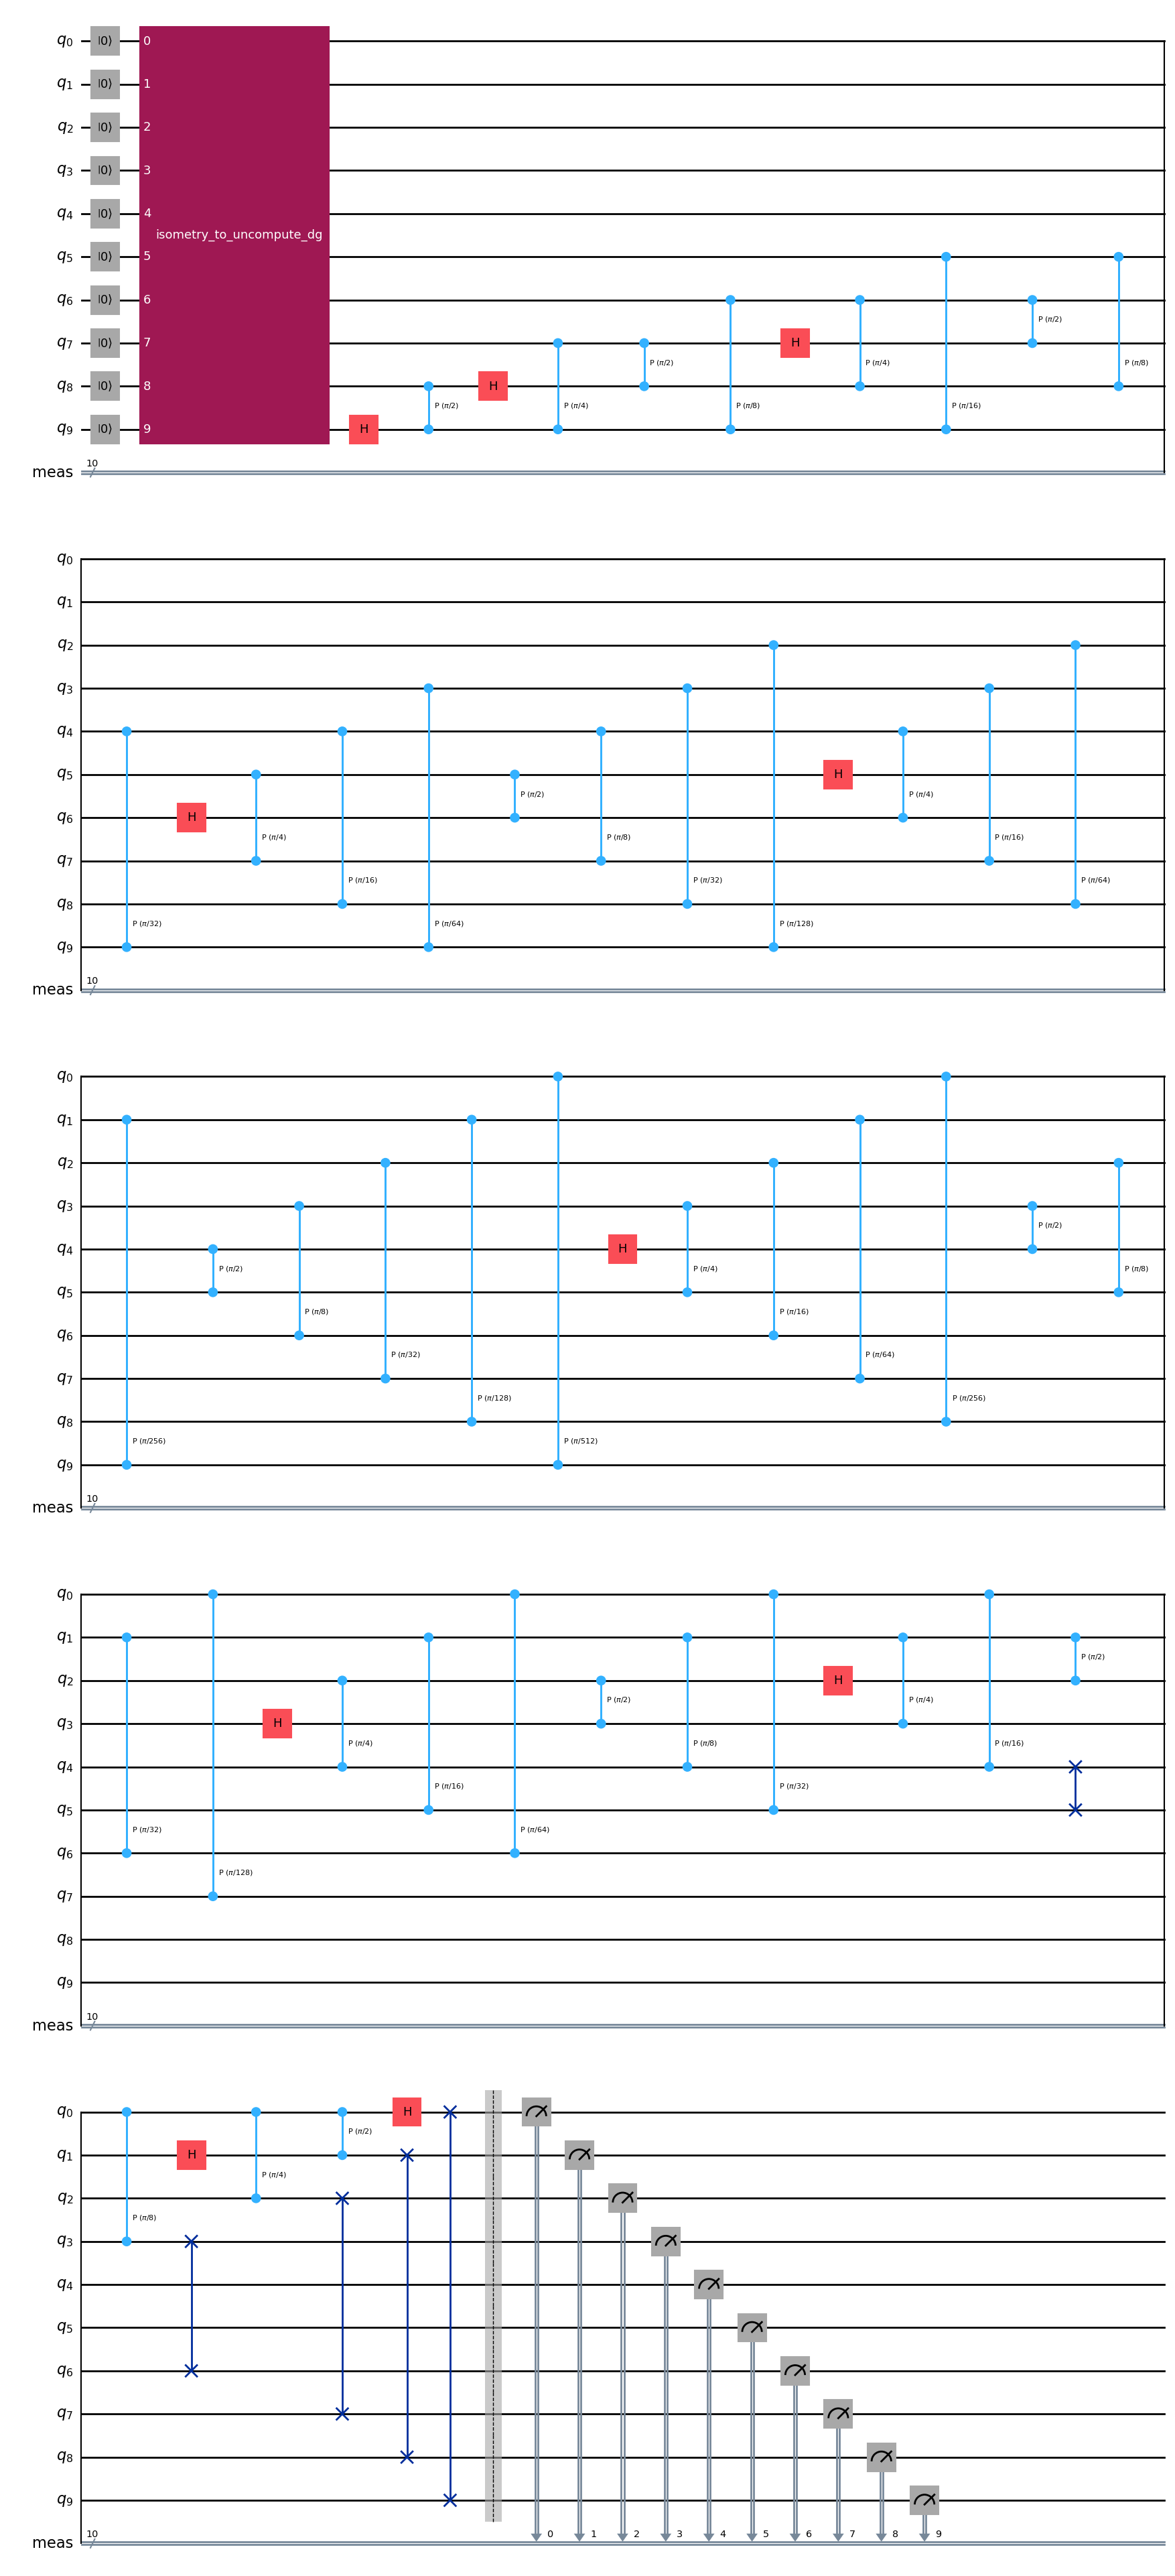

In [27]:
qc.decompose().decompose().draw("mpl")

In [28]:
# Run the AerSimulator
simulator = AerSimulator()
CompiledCircuit = transpile(qc, simulator)
job = simulator.run(CompiledCircuit, shots=10000)
result = job.result()
counts = result.get_counts()

# Plot the Magntiudes vs Frequency Components
plot_histogram(counts, title="Quantum Frequency Components (Magnitude Squared)", figsize=(12, 6))
plt.show()

## Question 3 
-------
If (b) is feasible, perform a simulation of your quantum circuit to extract the same information as in parts (a) (1) and (2).

[0.04747176 0.01814733 0.03830381 ... 0.00518867 0.01304969 0.02785495]
Quantum Simulated Dominant Frequencies:
Freq: 5.00 Hz | Prob: 0.4642 | Phase: 1.57 rad
Freq: 10.00 Hz | Prob: 0.2956 | Phase: -0.09 rad
Freq: 30.00 Hz | Prob: 0.2851 | Phase: 0.71 rad

Relative phase difference: 1.66 radians.


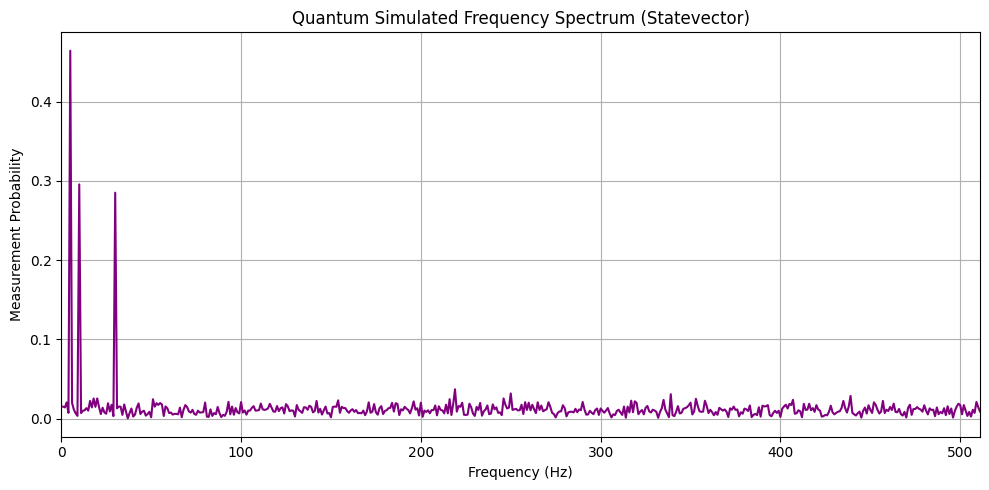

In [29]:
# Load the Datafile
df = pd.read_csv('raw_signal_data.csv', header=None, skiprows=1)
signal = df.iloc[:, 1].values
signal = signal.astype(float)

# Define some of the data properties
N = 1024
T = 1.0
dt = T / N

# Normalize the Signal
norm = np.linalg.norm(signal)
NormalizedSignal = signal / norm
print(NormalizedSignal)

# Create the Quantum Circuit
NQubits = 10
qc = QuantumCircuit(NQubits)

# Initialize the Circuit with the Normalized Signal
qc.initialize(NormalizedSignal, qc.qubits)

# Add the Built in QFT circuit
QFTCircuit = QFT(num_qubits=NQubits, approximation_degree=0, do_swaps=True, inverse=False)
qc.append(QFTCircuit, qc.qubits)

# Simulate the Circuit State without Measuring, this allows us to preserve the Phase of the data
state = Statevector(qc)
ComplexAmplitudes = np.asarray(state)

# Extract the Magnitudes and Phase
Phase = np.angle(ComplexAmplitudes)
QuantumAmplitudes = np.abs(ComplexAmplitudes)
QuantumMagnitudes = QuantumAmplitudes * (2.0 * norm / np.sqrt(N))

# Get the Frequency bins
frequencies = np.fft.fftfreq(N, d=dt)

# Get the Positive / Nyquist Frequencies only
NyquistMask = frequencies > 0
NyquistFreq = frequencies[NyquistMask]
NyquistProbabilities = QuantumMagnitudes[NyquistMask]
NyquistPhases = Phase[NyquistMask]


# 5. Find dominant frequencies and phase difference
threshold = np.max(NyquistProbabilities) * 0.1
PeakIndices = np.where(NyquistProbabilities > threshold)[0]

print("Quantum Simulated Dominant Frequencies:")
for idx in PeakIndices:
    print(f"Freq: {NyquistFreq[idx]:.2f} Hz | Prob: {NyquistProbabilities[idx]:.4f} | Phase: {NyquistPhases[idx]:.2f} rad")

if len(PeakIndices) >= 2:
    idx1, idx2 = PeakIndices[0], PeakIndices[1]
    phase_diff = abs(NyquistPhases[idx1] - NyquistPhases[idx2])
    print(f"\nRelative phase difference: {phase_diff:.2f} radians.")

# 6. Plotting
plt.figure(figsize=(10, 5))
plt.plot(NyquistFreq, NyquistProbabilities, color='purple')
plt.title('Quantum Simulated Frequency Spectrum (Statevector)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Measurement Probability')
plt.xlim(0, max(NyquistFreq))
plt.grid(True)
plt.tight_layout()
plt.show()